In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Handwritten Digit Classification — MNIST

In this project I explore the problem of handwritten digit recognition using the **MNIST dataset**, a widely used benchmark for image classification in machine learning. The goal is to build and evaluate neural network models capable of correctly identifying digits (0–9) from grayscale images.

The project begins with a simple **baseline model based on a Multilayer Perceptron (MLP)** in order to establish a reference performance for the task. Next, a **Convolutional Neural Network (CNN)** is implemented to take advantage of spatial information present in images.

After establishing the CNN baseline, a series of experiments is performed to analyze how different architectural and training choices influence model performance. These experiments include modifying the **network width and depth**, as well as applying common regularization techniques such as **Batch Normalization** and **Dropout**.

The objective of this project is not only to train an accurate model, but also to understand how various design decisions affect training dynamics, generalization ability, and classification performance. Model behavior is analyzed using training and validation curves, as well as confusion matrices that help identify which digits are most frequently misclassified.

In [1]:
# loading the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Example of digit: {y_train[0]}")
plt.axis('off')
plt.show()

NameError: name 'tf' is not defined

In [3]:
print(f"x_train: {X_train.shape}\nx_test: {X_test.shape}")
print(f"Type of data: {type(X_train[0])}")
ds_len = len(X_test) + len(X_train)

# counting the ratio of sets
def ds_percent(part):
    return np.round(len(part)/ds_len*100, 1)

print(f"Train/Test: {ds_percent(X_train)}/{ds_percent(X_test)}")

x_train: (60000, 28, 28)
x_test: (10000, 28, 28)
Type of data: <class 'numpy.ndarray'>
Train/Test: 85.7/14.3


# Normalizing and Standardizing the Data
Every pixel has a value between <0-255>. To normalize the data, I divided each value by 255.
In MNIST dataset mean is 0.1037 and standard deviation is 0.3081. To standardize the data, i will use the formula $z=\frac{x - \mu}{\sigma}$

In [4]:
X_train, X_test = (X_train/255.0).astype('float32'), (X_test/255.0).astype('float32')
mean = X_train.mean()
std = X_train.std()
X_train, X_test = (X_train - mean) / std, (X_test - mean) / std
print(X_train.mean())

-5.1035363e-07


# Creating a Dataset
First, we need to create a dataset class, so data is readable for torch, and make a training and testing set.

In [5]:
class MNISTDataset(Dataset):
    def __init__(self, data, labels):
        if len(data) != len(labels):
            raise ValueError("Dataset must have the same length as labels")
        self.data = data
        self.labels = labels
        if not isinstance(self.data, torch.Tensor):
            self.data = torch.from_numpy(self.data)
        if not isinstance(self.labels, torch.Tensor):
            self.labels = torch.from_numpy(self.labels)
        self.data = self.data.unsqueeze(1) # added a dimension of the channel (greyscale = 1) for conv2d layer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        return sample, label

train_full = MNISTDataset(X_train, y_train)
test_set = MNISTDataset(X_test, y_test)

# Extracting a Validation Set from Training Set
I decided on the ratio train/test/val 70/15/15.

In [6]:
val_size = 10000
train_size = len(train_full) - val_size
assert train_size + val_size == len(train_full)
train_set, val_set = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))
print(f"Train/Test/Val: {ds_percent(train_set)}/{ds_percent(test_set)}/{ds_percent(val_set)} {len(train_set)}/{len(test_set)}/{len(val_set)}")

Train/Test/Val: 71.4/14.3/14.3 50000/10000/10000


# Creating DataLoaders

In [7]:
batch_size = 128
train_loader  = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Data Visualisation

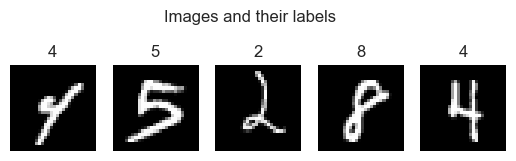

In [8]:
def show_img_label(imgs, labels, are_predicted):
    fig, ax = plt.subplots(1,len(imgs))
    for i in range(len(imgs)):
        ax[i].imshow(imgs[i], cmap='gray')
        ax[i].set_title(labels[i].item())
        ax[i].set_axis_off()
    if are_predicted:
        fig.suptitle('Images and the predicted values')
    else:
        fig.suptitle("Images and their labels", y=0.7)
    plt.show()

data_batch, labels_batch = next(iter(val_loader))
data_batch = data_batch[:5]
labels_batch = labels_batch[:5]
show_img_label(data_batch.squeeze(), labels_batch, False)


In [9]:
if torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Baseline Model
As a baseline, I used a simple fully connected neural network consisting of two linear layers with a ReLU activation function.
The input images are flattened and passed through the network to predict one of the ten digit classes.

The model is trained on the training set for 10 epochs using the Adam optimizer and cross-entropy loss.
A validation set is used to monitor the training process and evaluate the model's performance during training.

In [10]:
class BaselineNN(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, output_size=10):
        super(BaselineNN, self).__init__()
        self.layer1 = nn.Flatten()
        self.layer2 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        return x

epochs = 10
lr = 0.001
baseline_model = BaselineNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(baseline_model.parameters(), lr=lr)

def run_train_epoch(loader, model, optimizer, criterion):
    model.train()
    epoch_loss, correct, total = 0,0,0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)
        preds = predictions.argmax(1)
        correct += (preds==y_batch).sum().item()
        total += y_batch.size(0)
    return epoch_loss / total, correct / total

def run_val_epoch(loader, model, criterion):
    epoch_loss, correct, total = 0,0,0
    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)

            epoch_loss += loss.item() * x_batch.size(0)
            preds = predictions.argmax(1)
            correct += (preds==y_batch).sum().item()
            total += y_batch.size(0)
    return epoch_loss / total, correct / total



In [11]:
def run_epochs(epochs, train_loader, val_loader, model, optimizer, criterion):
    history = {
        "train_loss_arr": [], "train_acc_arr": [],
        "val_loss_arr":   [], "val_acc_arr":   []
    }
    for epoch in range(epochs):
        train_loss, train_accuracy = run_train_epoch(train_loader, model, optimizer, criterion)
        val_loss, val_accuracy = run_val_epoch(val_loader, model, criterion)

        history["train_loss_arr"].append(train_loss)
        history["train_acc_arr"].append(train_accuracy)

        history["val_loss_arr"].append(val_loss)
        history["val_acc_arr"].append(val_accuracy)

        print(f"Epoch: {epoch + 1}")
        print(f"Training: Loss: {train_loss}\tAccuracy: {train_accuracy}")
        print(f"Validation: Loss: {val_loss}\tAccuracy: {val_accuracy}")

    return history

history = run_epochs(epochs, train_loader, val_loader, baseline_model, optimizer, criterion)


Epoch: 1
Training: Loss: 0.32745578561782834	Accuracy: 0.90632
Validation: Loss: 0.18991238746643066	Accuracy: 0.943
Epoch: 2
Training: Loss: 0.14535313309669495	Accuracy: 0.95794
Validation: Loss: 0.14082721269130707	Accuracy: 0.9578
Epoch: 3
Training: Loss: 0.10105678107976913	Accuracy: 0.97048
Validation: Loss: 0.1116025004863739	Accuracy: 0.9651
Epoch: 4
Training: Loss: 0.07672346586465835	Accuracy: 0.9773
Validation: Loss: 0.10884224260002374	Accuracy: 0.9671
Epoch: 5
Training: Loss: 0.061104207270145414	Accuracy: 0.98206
Validation: Loss: 0.10154581200182437	Accuracy: 0.9685
Epoch: 6
Training: Loss: 0.04860510041117668	Accuracy: 0.98564
Validation: Loss: 0.08837283929511905	Accuracy: 0.9722
Epoch: 7
Training: Loss: 0.03920967523217201	Accuracy: 0.98816
Validation: Loss: 0.0893050756931305	Accuracy: 0.9724
Epoch: 8
Training: Loss: 0.03155012840628624	Accuracy: 0.99072
Validation: Loss: 0.08791797857657074	Accuracy: 0.9725
Epoch: 9
Training: Loss: 0.026355625603795053	Accuracy: 0.9

# Monitoring the training process

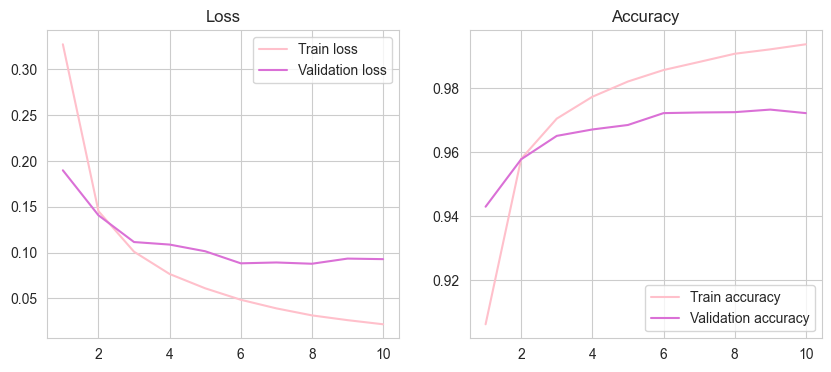

In [12]:
def show_training_process(train_los, val_los, train_acc, val_acc):
    x = []
    for i in range(len(train_los)):
        x.append(i+1)
    x = np.array(x)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(x, train_los, label='Train loss', color='pink')
    plt.plot(x, val_los, label='Validation loss', color='orchid')
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(x, train_acc, label='Train accuracy', color='pink')
    plt.plot(x, val_acc, label='Validation accuracy', color='orchid')
    plt.title("Accuracy")
    plt.legend()
    plt.show()

show_training_process(history["train_loss_arr"], history["val_loss_arr"], history["train_acc_arr"], history["val_acc_arr"])

# Final Results for Baseline Model
This result serves as a reference point for evaluating more advanced architectures such as convolutional neural networks.

In [13]:
loss, accuracy = run_val_epoch(test_loader, baseline_model, criterion)
print("Baseline Test Performance: ")
print(f"Accuracy: {np.round(accuracy, 2)}")
print(f"Loss: {np.round(loss,2)}")

Baseline Test Performance: 
Accuracy: 0.98
Loss: 0.08


# CNN Model

In [14]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.conv1(x)) # 8 features
        x = self.pool(self.relu(self.conv2(x))) # 16 features img 14x14
        x = self.pool(self.relu(self.conv3(x))) # 24 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_model = CNNModel().to(device)

# Training of CNN Model
After 7 epochs, the training accuracy keeps increasing (up to 0.9966), while the validation accuracy plateaus around ~0.989.
The best validation accuracy (0.9895) is achieved at epoch 7. After that point, validation performance fluctuates slightly and does not improve. It suggests diminishing returns from additional training and the beginning of overfitting. Therefore, epoch 7 can be treated as the optimal checkpoint for this baseline model.

Epoch: 1
Training: Loss: 0.2988552198839188	Accuracy: 0.90954
Validation: Loss: 0.10872613778114319	Accuracy: 0.9669
Epoch: 2
Training: Loss: 0.07301846069335938	Accuracy: 0.97696
Validation: Loss: 0.06254071375131608	Accuracy: 0.9828
Epoch: 3
Training: Loss: 0.05114289430975914	Accuracy: 0.9843
Validation: Loss: 0.056486608344316486	Accuracy: 0.9846
Epoch: 4
Training: Loss: 0.039129950242638586	Accuracy: 0.98792
Validation: Loss: 0.05557391369342804	Accuracy: 0.9836
Epoch: 5
Training: Loss: 0.03153007661342621	Accuracy: 0.9897
Validation: Loss: 0.04554349823892116	Accuracy: 0.9862
Epoch: 6
Training: Loss: 0.02622831313751638	Accuracy: 0.99208
Validation: Loss: 0.05060905451178551	Accuracy: 0.9854
Epoch: 7
Training: Loss: 0.020337592556998133	Accuracy: 0.99378
Validation: Loss: 0.052152757155895235	Accuracy: 0.9862
Epoch: 8
Training: Loss: 0.018451721250116824	Accuracy: 0.9941
Validation: Loss: 0.05076275309622288	Accuracy: 0.9862
Epoch: 9
Training: Loss: 0.016830909724980594	Accuracy:

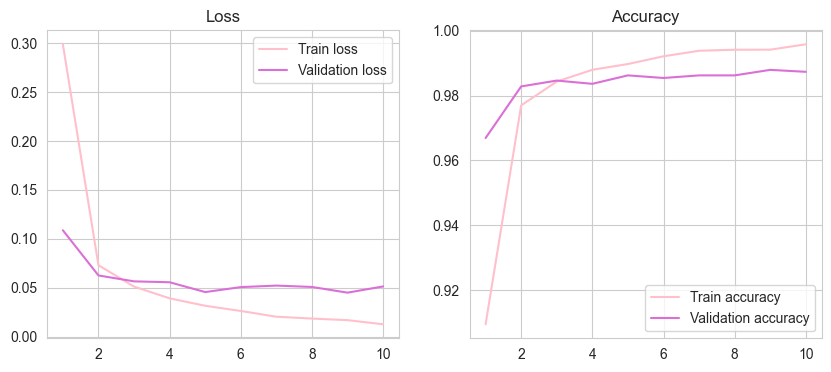

In [15]:
optimizer = Adam(cnn_model.parameters(), lr=lr)

history = run_epochs(epochs, train_loader, val_loader, cnn_model, optimizer, criterion)
show_training_process(history["train_loss_arr"], history["val_loss_arr"], history["train_acc_arr"], history["val_acc_arr"])

In addition to accuracy, a confusion matrix is presented to analyze which digits are most frequently misclassified.


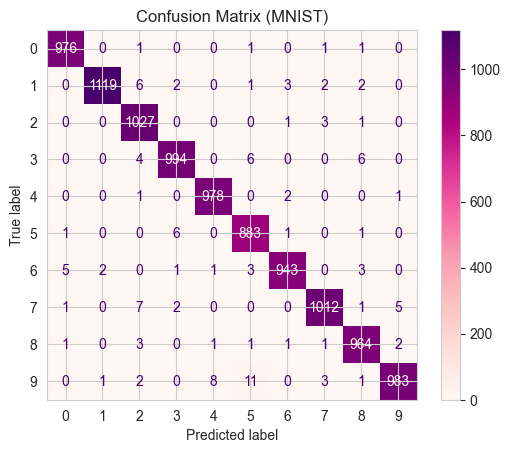

Test accuracy: 0.9879


In [16]:
cnn_model.eval()
all_predictions, all_targets = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds = cnn_model(x_batch)
        preds = preds.argmax(1).cpu().numpy()
        all_predictions.append(preds)
        all_targets.append(y_batch.numpy())

all_predictions = np.concatenate(all_predictions)
all_targets = np.concatenate(all_targets)

labels = list(range(10))
cm = confusion_matrix(all_targets, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot(cmap='RdPu')
plt.title("Confusion Matrix (MNIST)")
plt.show()

acc = (all_predictions == all_targets).mean()
print(f"Test accuracy: {np.round(acc,4)}")

# Hyperparameter Tuning
I chose accuracy as the main evaluation metric because MNIST is a balanced multi-class classification problem. Therefore, accuracy directly reflects the proportion of correctly classified images and is easy to interpret. My plan of experiments with hyperparameter tuning is as follows:
- network width (more channels)
- network depth (more convolutional layers)
- Batch Normalization
- Dropout


## 1. More Channels
Increasing the number of convolutional channels did not significantly change the model performance.
The training accuracy reached values similar to the baseline model, while the validation accuracy remained around 0.988–0.989 and did not exceed 0.99. This indicates that increasing the network width did not provide a noticeable improvement for this task.

In [17]:
class CNN_wider(nn.Module):
    def __init__(self):
        super(CNN_wider, self).__init__()
        self.conv1 = nn.Conv2d(1,16,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(16,32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(32,64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3136, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.conv1(x)) # 16 features
        x = self.pool(self.relu(self.conv2(x))) # 32 features img 14x14
        x = self.pool(self.relu(self.conv3(x))) # 64 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_wider = CNN_wider().to(device)

In [18]:
epochs = 7
optimizer = Adam(cnn_wider.parameters(), lr=lr)
history = run_epochs(epochs, train_loader, val_loader, cnn_wider, optimizer, criterion)

Epoch: 1
Training: Loss: 0.2156149704360962	Accuracy: 0.93368
Validation: Loss: 0.07091433256864547	Accuracy: 0.9784
Epoch: 2
Training: Loss: 0.05204866535782814	Accuracy: 0.98364
Validation: Loss: 0.04679469417333603	Accuracy: 0.9845
Epoch: 3
Training: Loss: 0.034750366061031816	Accuracy: 0.9892
Validation: Loss: 0.04187015824019909	Accuracy: 0.9881
Epoch: 4
Training: Loss: 0.027131280239224433	Accuracy: 0.99126
Validation: Loss: 0.03768979015126824	Accuracy: 0.9889
Epoch: 5
Training: Loss: 0.020311804877966643	Accuracy: 0.99308
Validation: Loss: 0.043637266159057615	Accuracy: 0.9865
Epoch: 6
Training: Loss: 0.015983187225982548	Accuracy: 0.9945
Validation: Loss: 0.03588847773652524	Accuracy: 0.9895
Epoch: 7
Training: Loss: 0.012360451024025679	Accuracy: 0.99582
Validation: Loss: 0.04193692316859961	Accuracy: 0.9881


## 2. More Convolutional Layers
Increasing network depth (adding an additional convolutional layer) did not improve validation performance.
Validation accuracy remained in a similar range and did not surpass the baseline CNN results.
This suggests that the baseline architecture is already sufficient for MNIST and the extra depth mainly increases model capacity without improving generalization.

In [19]:
class CNN_deeper(nn.Module):
    def __init__(self):
        super(CNN_deeper, self).__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(24,24, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)

    def forward(self,x):
        x = self.relu(self.conv1(x)) # 8 features
        x = self.pool(self.relu(self.conv2(x))) # 16 features img 14x14
        x = self.relu(self.conv3(x)) # 24 features img 14x14
        x = self.pool(self.relu(self.conv4(x))) # 24 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_deeper = CNN_deeper().to(device)

In [20]:
optimizer = Adam(cnn_deeper.parameters(), lr=lr)
history = run_epochs(epochs, train_loader, val_loader, cnn_deeper, optimizer, criterion)

Epoch: 1
Training: Loss: 0.28240663189888	Accuracy: 0.91222
Validation: Loss: 0.08671164166927338	Accuracy: 0.9736
Epoch: 2
Training: Loss: 0.06752552650690079	Accuracy: 0.979
Validation: Loss: 0.06606265450119972	Accuracy: 0.9802
Epoch: 3
Training: Loss: 0.047349985647946596	Accuracy: 0.98526
Validation: Loss: 0.056158575159311296	Accuracy: 0.9832
Epoch: 4
Training: Loss: 0.03649399397134781	Accuracy: 0.9889
Validation: Loss: 0.04557699847817421	Accuracy: 0.9864
Epoch: 5
Training: Loss: 0.030224467833042144	Accuracy: 0.99084
Validation: Loss: 0.04147077035307884	Accuracy: 0.9882
Epoch: 6
Training: Loss: 0.02463990760833025	Accuracy: 0.99186
Validation: Loss: 0.06072128247842193	Accuracy: 0.9821
Epoch: 7
Training: Loss: 0.019838688842654228	Accuracy: 0.99372
Validation: Loss: 0.04065900432690978	Accuracy: 0.9893


## 3. Batch Normalization
Adding Batch Normalization did not lead to a significant improvement in validation performance. The validation accuracy slightly increased but remained below the 0.99 threshold, reaching a maximum of 0.9894. Therefore, the overall performance is comparable to the baseline CNN.

In [21]:
class CNN_batch(nn.Module):
    def __init__(self):
        super(CNN_batch, self).__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(24)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x))) # 8 features
        x = self.pool(self.relu(self.bn2(self.conv2(x)))) # 16 features img 14x14
        x = self.pool(self.relu(self.bn3(self.conv3(x)))) # 24 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_batch = CNN_batch().to(device)

In [22]:
optimizer = Adam(cnn_batch.parameters(), lr=lr)
history = run_epochs(epochs, train_loader, val_loader, cnn_batch, optimizer, criterion)

Epoch: 1
Training: Loss: 0.18367667432785034	Accuracy: 0.9471
Validation: Loss: 0.07582405836582184	Accuracy: 0.9765
Epoch: 2
Training: Loss: 0.05421548246562481	Accuracy: 0.98246
Validation: Loss: 0.05782604329586029	Accuracy: 0.9813
Epoch: 3
Training: Loss: 0.04065427640259266	Accuracy: 0.98746
Validation: Loss: 0.07989895784854889	Accuracy: 0.9756
Epoch: 4
Training: Loss: 0.029848268674314022	Accuracy: 0.9908
Validation: Loss: 0.06664229752421379	Accuracy: 0.9792
Epoch: 5
Training: Loss: 0.025429913804754616	Accuracy: 0.99212
Validation: Loss: 0.041648188537359236	Accuracy: 0.9869
Epoch: 6
Training: Loss: 0.020438132442086934	Accuracy: 0.99362
Validation: Loss: 0.05076574667096138	Accuracy: 0.9864
Epoch: 7
Training: Loss: 0.01798804460555315	Accuracy: 0.99418
Validation: Loss: 0.04328723815083504	Accuracy: 0.9867


## 4. Dropout
The best results were obtained with the model using Dropout and a larger batch size. The validation accuracy exceeded the 0.99 threshold, reaching 0.9909 at epoch 7. Compared to previous experiments (baseline, wider network, deeper network and BatchNorm), this configuration achieved the highest validation performance while maintaining a small gap between training and validation accuracy. As this is the best-performing model, it will be evaluated on the test dataset and a confusion matrix will be generated to compare its performance with the baseline CNN model.

In [25]:
class CNN_dropout(nn.Module):
    def __init__(self):
        super(CNN_dropout, self).__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.conv1(x)) # 8 features
        x = self.pool(self.relu(self.conv2(x)))# 16 features img 14x14
        x = self.pool(self.relu(self.conv3(x))) # 24 features img 7x7

        x = self.flatten(x)
        x = self.dropout(x)

        x = self.relu(self.fc1(x))
        x = self.output(x)
        return x

cnn_dropout = CNN_dropout().to(device)

In [26]:
epochs = 10
optimizer = Adam(cnn_dropout.parameters(), lr = lr)
history = run_epochs(epochs, train_loader, val_loader, cnn_dropout, optimizer, criterion)

Epoch: 1
Training: Loss: 0.3123394163608551	Accuracy: 0.90426
Validation: Loss: 0.09119169671535492	Accuracy: 0.971
Epoch: 2
Training: Loss: 0.08369226879358292	Accuracy: 0.97408
Validation: Loss: 0.057262646627426146	Accuracy: 0.9818
Epoch: 3
Training: Loss: 0.06026873165607453	Accuracy: 0.98108
Validation: Loss: 0.04732613030672073	Accuracy: 0.987
Epoch: 4
Training: Loss: 0.04924437238752842	Accuracy: 0.9849
Validation: Loss: 0.048705560213327406	Accuracy: 0.9842
Epoch: 5
Training: Loss: 0.04286514212846756	Accuracy: 0.98608
Validation: Loss: 0.03909132208824158	Accuracy: 0.9883
Epoch: 6
Training: Loss: 0.035173430643677714	Accuracy: 0.9886
Validation: Loss: 0.0473130624294281	Accuracy: 0.9864
Epoch: 7
Training: Loss: 0.03228054766267538	Accuracy: 0.98952
Validation: Loss: 0.03272869527488947	Accuracy: 0.9909
Epoch: 8
Training: Loss: 0.028203825857490303	Accuracy: 0.9908
Validation: Loss: 0.03779158479422331	Accuracy: 0.9887
Epoch: 9
Training: Loss: 0.025763307190537453	Accuracy: 0.9

Confusion matrix of dropout layer shows much higher accuracy: 0.9917. This is the highest obtained value, proving that with MNIST using dropout layer with p=0.3 is a good choice.

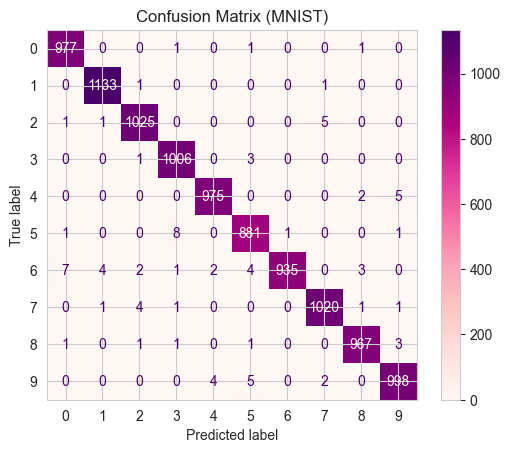

Test accuracy: 0.9917


In [27]:
cnn_dropout.eval()
all_predictions, all_targets = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds = cnn_dropout(x_batch)
        preds = preds.argmax(1).cpu().numpy()
        all_predictions.append(preds)
        all_targets.append(y_batch.numpy())

all_predictions = np.concatenate(all_predictions)
all_targets = np.concatenate(all_targets)

labels = list(range(10))
cm = confusion_matrix(all_targets, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot(cmap='RdPu')
plt.title("Confusion Matrix (MNIST)")
plt.show()

acc = (all_predictions == all_targets).mean()
print(f"Test accuracy: {np.round(acc,4)}")

# Summary

In this project I implemented and compared several neural network architectures for digit classification on the MNIST dataset.

As a starting point, I trained a simple **Multilayer Perceptron (MLP)** model to establish a basic performance baseline. Since this model does not use spatial information from the images, it serves as a reference for how well a fully connected network performs on this task.

Next, I implemented a **baseline convolutional neural network (CNN)**, which achieved a test accuracy of **0.9879**. This model served as the main reference point for further CNN architecture experiments.

Several architectural modifications were then explored:
- increasing the number of convolutional channels
- increasing the network depth
- adding Batch Normalization
- adding Dropout

The experiments showed that increasing the network width and depth did not significantly improve performance — validation accuracy remained around **0.988–0.989**. Adding Batch Normalization stabilized training but also did not lead to a noticeable accuracy gain.

The best results were obtained when introducing **Dropout (p = 0.3)** together with a larger batch size. This configuration achieved a test accuracy of **0.9917**, outperforming the baseline CNN.

To better understand model performance, confusion matrices were generated for both the baseline CNN and the final CNN with Dropout, allowing a comparison of the most common misclassifications.